In [1]:
!pip install pybaseball
from pybaseball import batting_stats, pitching_stats, playerid_lookup

# 오타니 선수 ID 조회
ohtani = playerid_lookup('ohtani', 'shohei')
print(ohtani)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.3 MB/s eta 0:00:00
Gathering player lookup table. This may take a moment.
  name_last name_first  key_mlbam key_retro  key_bbref  key_fangraphs  \
0    ohtani     shohei     660271  ohtas001  ohtansh01          19755   

   mlb_played_first  mlb_played_last  
0            2018.0           2026.0  


In [2]:
from pybaseball import batting_stats

# 2018~2025 전체 타격 스탯
batting = batting_stats(2018, 2025, qual=0)

# 오타니만 필터링
ohtani_batting = batting[batting['IDfg'] == 19755]
ohtani_batting[['Season', 'G', 'AB', 'HR', 'RBI', 'AVG', 'OBP', 'SLG', 'OPS', 'WAR']].reset_index(drop=True)

HTTPError: Error accessing 'https://www.fangraphs.com/leaders-legacy.aspx'. Received status code 403

In [3]:
from pybaseball import statcast_batter

# Ohtani's MLB ID: 660271
ohtani_statcast = statcast_batter('2018-01-01', '2025-12-31', player_id=660271)

print(ohtani_statcast.shape)
ohtani_statcast.head()

Gathering Player Data
(18605, 119)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,SL,2023-09-03,88.7,2.17,6.01,"Ohtani, Shohei",660271,666205,field_out,hit_into_play,...,NaN,2.55,-0.06,-0.06,37.4,12.219779,-5.122073,32.329231,33.963044,28.628391
1,CU,2023-09-03,83.9,1.96,6.19,"Ohtani, Shohei",660271,666205,NaN,ball,...,NaN,3.67,-0.28,-0.28,38.3,NaN,NaN,NaN,NaN,NaN
2,CU,2023-09-03,82.3,2.01,6.20,"Ohtani, Shohei",660271,666205,NaN,ball,...,NaN,4.13,-0.50,-0.50,36.3,NaN,NaN,NaN,NaN,NaN
3,FF,2023-09-03,94.3,1.92,6.02,"Ohtani, Shohei",660271,666205,NaN,foul,...,NaN,1.33,0.57,0.57,38.8,4.148418,8.099228,29.921379,39.015942,21.842380
4,FF,2023-09-03,93.9,2.07,5.83,"Ohtani, Shohei",660271,666205,NaN,swinging_strike,...,NaN,1.45,0.73,0.73,33.2,24.270255,-21.742199,36.778124,30.015056,42.237859


In [4]:
import sqlite3
import pandas as pd

# Create SQLite DB
conn = sqlite3.connect('ohtani_analysis.db')

# Save Statcast data as a table
ohtani_statcast.to_sql('statcast', conn, if_exists='replace', index=False)

# Verify
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM statcast")
print(f"Total rows: {cursor.fetchone()[0]}")

# Check columns
cursor.execute("PRAGMA table_info(statcast)")
cols = [row[1] for row in cursor.fetchall()]
print(f"\nTotal columns: {len(cols)}")
print(cols[:20])  # First 20 columns

Total rows: 18605

Total columns: 119
['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team']


In [6]:
query = """
SELECT
    game_date,
    pitch_type,
    release_speed,
    launch_speed,
    launch_angle,
    events
FROM statcast
WHERE events IS NOT NULL
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
result

,game_date,pitch_type,release_speed,launch_speed,launch_angle,events
0,2023-09-03,SL,88.7,66.7,74.0,field_out
1,2023-09-03,SL,82.7,NaN,NaN,strikeout
2,2023-09-03,FF,94.6,NaN,NaN,walk
3,2023-09-03,FF,94.3,NaN,NaN,walk
4,2023-09-03,SL,82.3,NaN,NaN,strikeout
5,2023-09-02,CH,86.1,75.6,-24.0,field_out
6,2023-09-02,SI,93.3,NaN,NaN,walk
7,2023-09-02,CU,76.9,83.7,65.0,field_out
8,2023-09-02,None,NaN,NaN,NaN,intent_walk
9,2023-09-02,None,NaN,NaN,NaN,intent_walk


In [7]:
query = """
SELECT
    pitch_type,
    COUNT(*) AS total_pitches,
    ROUND(AVG(release_speed), 1) AS avg_speed
FROM statcast
WHERE pitch_type IS NOT NULL
GROUP BY pitch_type
ORDER BY total_pitches DESC
"""

result = pd.read_sql_query(query, conn)
result

,pitch_type,total_pitches,avg_speed
0,FF,5573,94.4
1,CH,2585,86.0
2,SL,2570,85.4
3,SI,2436,93.1
4,FC,1455,89.6
5,CU,1247,79.5
6,ST,844,81.8
7,FS,632,86.6
8,KC,451,82.3
9,SV,99,81.5


In [8]:
query = """
SELECT
    pitch_type,
    COUNT(*) AS total_pitches,
    SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
    SUM(CASE WHEN events IN ('single','double','triple','home_run') THEN 1 ELSE 0 END) AS hits,
    ROUND(AVG(launch_speed), 1) AS avg_exit_velo
FROM statcast
WHERE pitch_type IS NOT NULL
    AND events IS NOT NULL
GROUP BY pitch_type
ORDER BY home_runs DESC
"""

result = pd.read_sql_query(query, conn)
result

,pitch_type,total_pitches,home_runs,hits,avg_exit_velo
0,FF,1321,92,328,96.9
1,SL,650,47,151,93.1
2,SI,623,42,176,94.1
3,CH,654,31,150,90.0
4,FC,365,29,97,92.6
5,CU,302,22,73,93.1
6,ST,213,14,43,91.6
7,FS,160,9,36,92.4
8,KC,126,5,35,91.6
9,SV,33,3,6,96.2


In [9]:
query = """
SELECT
    SUBSTR(game_date, 1, 4) AS season,
    COUNT(*) AS total_pitches,
    SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
    ROUND(AVG(launch_speed), 1) AS avg_exit_velo,
    ROUND(AVG(launch_angle), 1) AS avg_launch_angle
FROM statcast
WHERE events IS NOT NULL
GROUP BY season
ORDER BY season
"""

result = pd.read_sql_query(query, conn)
result

,season,total_pitches,home_runs,avg_exit_velo,avg_launch_angle
0,2018,402,22,92.5,12.5
1,2019,425,18,92.8,6.7
2,2020,204,7,89.3,9.3
3,2021,675,51,92.9,16.2
4,2022,700,37,92.7,11.7
5,2023,612,44,94.4,13.4
6,2024,841,59,95.3,16.2
7,2025,838,64,95.1,15.0


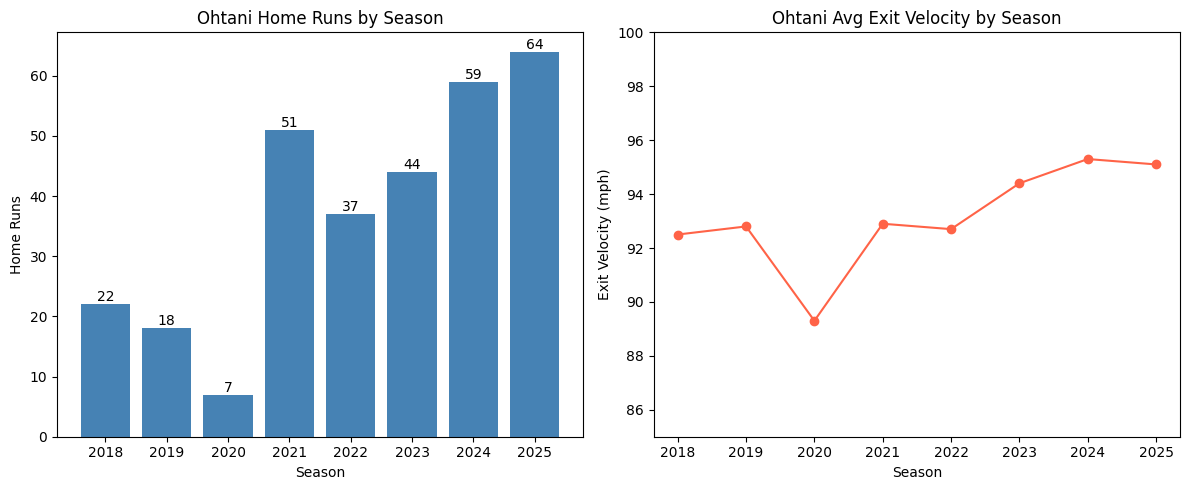

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Home runs by season
axes[0].bar(result['season'], result['home_runs'], color='steelblue')
axes[0].set_title('Ohtani Home Runs by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Home Runs')
for i, v in enumerate(result['home_runs']):
    axes[0].text(i, v + 0.5, str(v), ha='center')

# Avg exit velocity by season
axes[1].plot(result['season'], result['avg_exit_velo'], marker='o', color='tomato')
axes[1].set_title('Ohtani Avg Exit Velocity by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Exit Velocity (mph)')
axes[1].set_ylim(85, 100)

plt.tight_layout()
plt.show()

In [11]:
query = """
SELECT
    season,
    home_runs,
    avg_exit_velo
FROM (
    SELECT
        SUBSTR(game_date, 1, 4) AS season,
        SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
        ROUND(AVG(launch_speed), 1) AS avg_exit_velo
    FROM statcast
    WHERE events IS NOT NULL
    GROUP BY season
) AS season_stats
WHERE home_runs > (
    SELECT AVG(home_runs)
    FROM (
        SELECT
            SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs
        FROM statcast
        WHERE events IS NOT NULL
        GROUP BY SUBSTR(game_date, 1, 4)
    )
)
ORDER BY home_runs DESC
"""

result = pd.read_sql_query(query, conn)
result

,season,home_runs,avg_exit_velo
0,2025,64,95.1
1,2024,59,95.3
2,2021,51,92.9
3,2023,44,94.4


In [12]:
query = """
SELECT
    SUBSTR(game_date, 1, 4) AS season,
    COUNT(*) AS total_pitches,
    SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
    ROUND(AVG(launch_speed), 1) AS avg_exit_velo
FROM statcast
WHERE events IS NOT NULL
    AND (
        (SUBSTR(game_date, 1, 4) = '2025' AND game_date <= '2025-09-28')
        OR SUBSTR(game_date, 1, 4) != '2025'
    )
GROUP BY season
ORDER BY season
"""

result = pd.read_sql_query(query, conn)
result

,season,home_runs,avg_exit_velo
0,2025,64,95.1
1,2024,59,95.3
2,2021,51,92.9
3,2023,44,94.4


In [13]:
# Check what game_type values exist
query = """
SELECT DISTINCT game_type, COUNT(*) as cnt
FROM statcast
GROUP BY game_type
ORDER BY cnt DESC
"""
result = pd.read_sql_query(query, conn)
result

,game_type,cnt
0,R,17364
1,S,597
2,W,219
3,L,204
4,D,178
5,F,43


In [14]:
query = """
SELECT
    SUBSTR(game_date, 1, 4) AS season,
    COUNT(*) AS total_pitches,
    SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
    ROUND(AVG(launch_speed), 1) AS avg_exit_velo,
    ROUND(AVG(launch_angle), 1) AS avg_launch_angle
FROM statcast
WHERE events IS NOT NULL
    AND game_type = 'R'
GROUP BY season
ORDER BY season
"""

result = pd.read_sql_query(query, conn)
result

,season,total_pitches,home_runs,avg_exit_velo,avg_launch_angle
0,2018,366,22,92.6,12.3
1,2019,425,18,92.8,6.7
2,2020,175,7,89.1,9.2
3,2021,640,46,92.9,16.3
4,2022,666,34,92.7,11.7
5,2023,599,44,94.4,13.2
6,2024,731,54,95.7,16.0
7,2025,727,55,94.9,15.0


In [16]:
query = """
SELECT season, home_runs, avg_exit_velo
FROM (
    SELECT
        SUBSTR(game_date, 1, 4) AS season,
        SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
        ROUND(AVG(launch_speed), 1) AS avg_exit_velo
    FROM statcast
    WHERE events IS NOT NULL
        AND game_type = 'R'
    GROUP BY season
) AS season_stats
WHERE home_runs > (
    SELECT AVG(home_runs) FROM (
        SELECT SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs
        FROM statcast
        WHERE events IS NOT NULL
            AND game_type = 'R'
        GROUP BY SUBSTR(game_date, 1, 4)
    )
)
ORDER BY home_runs DESC
"""

result = pd.read_sql_query(query, conn)
result

,season,home_runs,avg_exit_velo
0,2025,55,94.9
1,2024,54,95.7
2,2021,46,92.9
3,2023,44,94.4


In [17]:
query = """
SELECT
    season,
    home_runs,
    avg_exit_velo,
    RANK() OVER (ORDER BY home_runs DESC) AS hr_rank,
    LAG(home_runs, 1) OVER (ORDER BY season) AS prev_season_hr,
    home_runs - LAG(home_runs, 1) OVER (ORDER BY season) AS hr_change
FROM (
    SELECT
        SUBSTR(game_date, 1, 4) AS season,
        SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
        ROUND(AVG(launch_speed), 1) AS avg_exit_velo
    FROM statcast
    WHERE events IS NOT NULL
        AND game_type = 'R'
    GROUP BY season
)
ORDER BY season
"""

result = pd.read_sql_query(query, conn)
result

,season,home_runs,avg_exit_velo,hr_rank,prev_season_hr,hr_change
0,2018,22,92.6,6,NaN,NaN
1,2019,18,92.8,7,22.0,-4.0
2,2020,7,89.1,8,18.0,-11.0
3,2021,46,92.9,3,7.0,39.0
4,2022,34,92.7,5,46.0,-12.0
5,2023,44,94.4,4,34.0,10.0
6,2024,54,95.7,2,44.0,10.0
7,2025,55,94.9,1,54.0,1.0


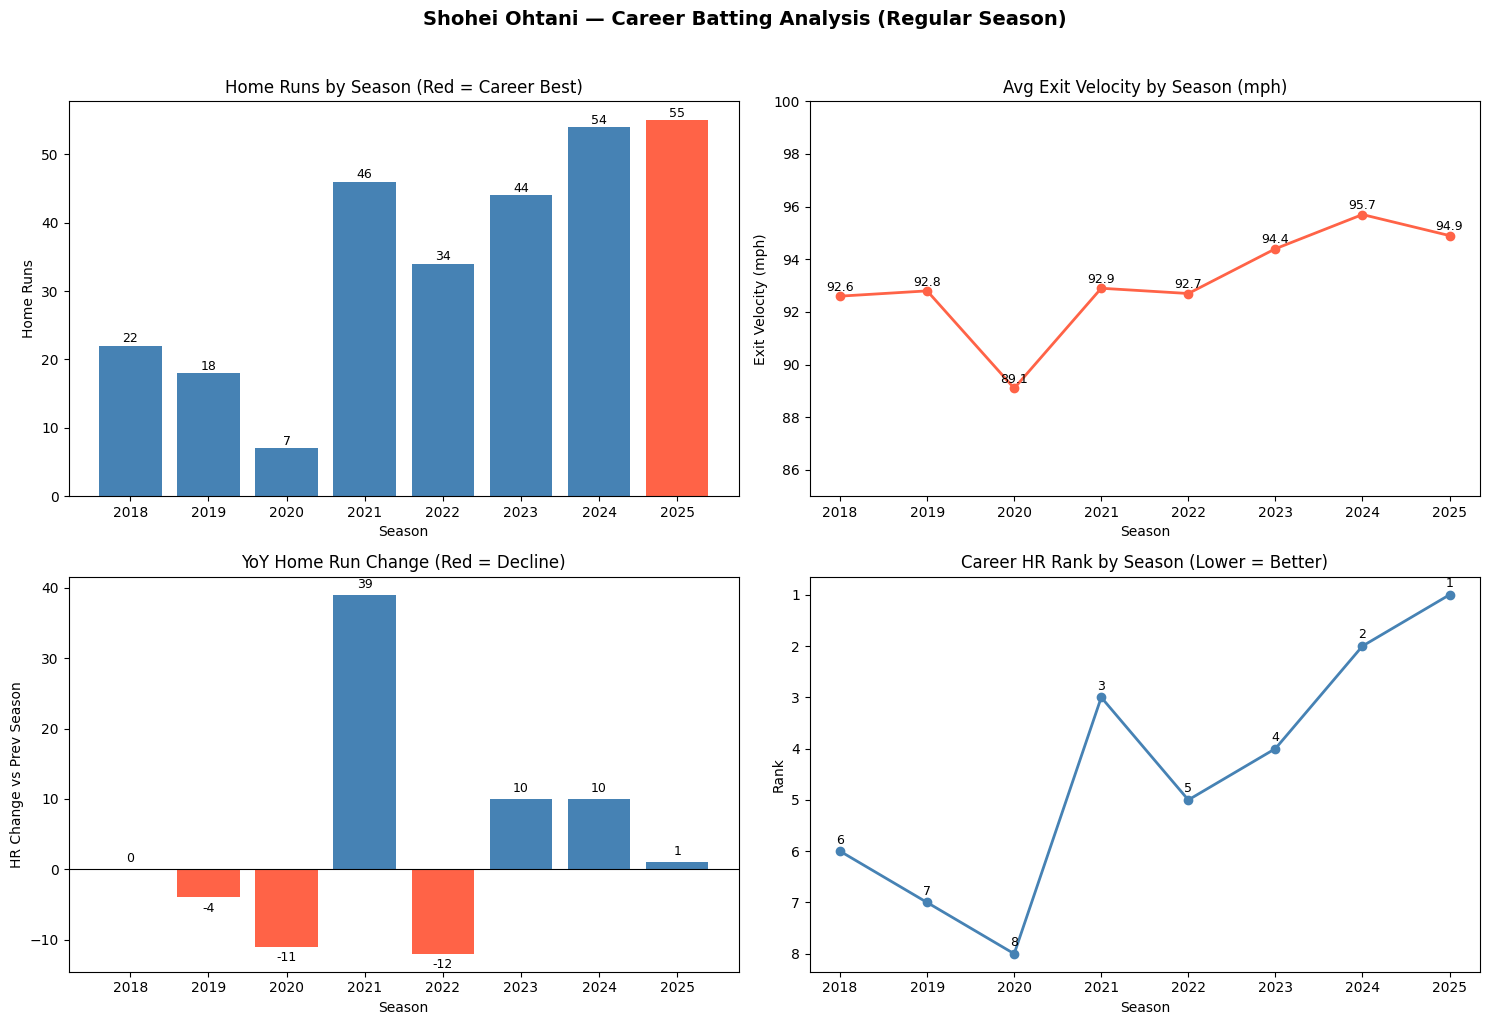

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Store window function result as 'season_df'
season_df = result.copy()

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# 1) Home Runs by Season (bar)
ax1 = fig.add_subplot(gs[0, 0])
colors = ['tomato' if r == 1 else 'steelblue' for r in season_df['hr_rank']]
ax1.bar(season_df['season'], season_df['home_runs'], color=colors)
ax1.set_title('Home Runs by Season (Red = Career Best)')
ax1.set_xlabel('Season')
ax1.set_ylabel('Home Runs')
for i, v in enumerate(season_df['home_runs']):
    ax1.text(i, v + 0.5, str(v), ha='center', fontsize=9)

# 2) Avg Exit Velocity trend (line)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(season_df['season'], season_df['avg_exit_velo'], marker='o', color='tomato', linewidth=2)
ax2.set_title('Avg Exit Velocity by Season (mph)')
ax2.set_xlabel('Season')
ax2.set_ylabel('Exit Velocity (mph)')
ax2.set_ylim(85, 100)
for i, v in enumerate(season_df['avg_exit_velo']):
    ax2.text(season_df['season'].iloc[i], v + 0.2, str(v), ha='center', fontsize=9)

# 3) YoY HR Change (bar)
ax3 = fig.add_subplot(gs[1, 0])
hr_change = season_df['hr_change'].fillna(0)
colors2 = ['tomato' if x < 0 else 'steelblue' for x in hr_change]
ax3.bar(season_df['season'], hr_change, color=colors2)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_title('YoY Home Run Change (Red = Decline)')
ax3.set_xlabel('Season')
ax3.set_ylabel('HR Change vs Prev Season')
for i, v in enumerate(hr_change):
    ax3.text(i, v + (1 if v >= 0 else -2), str(int(v)), ha='center', fontsize=9)

# 4) HR Rank over seasons (line)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(season_df['season'], season_df['hr_rank'], marker='o', color='steelblue', linewidth=2)
ax4.invert_yaxis()  # Rank 1 at top
ax4.set_title('Career HR Rank by Season (Lower = Better)')
ax4.set_xlabel('Season')
ax4.set_ylabel('Rank')
for i, v in enumerate(season_df['hr_rank']):
    ax4.text(season_df['season'].iloc[i], v - 0.15, str(int(v)), ha='center', fontsize=9)

plt.suptitle("Shohei Ohtani — Career Batting Analysis (Regular Season)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Save season stats for Tableau
season_df.to_csv('ohtani_season_stats.csv', index=False)

# Save pitch type analysis for Tableau
query = """
SELECT
    pitch_type,
    COUNT(*) AS total_pitches,
    SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) AS home_runs,
    SUM(CASE WHEN events IN ('single','double','triple','home_run') THEN 1 ELSE 0 END) AS hits,
    ROUND(AVG(launch_speed), 1) AS avg_exit_velo
FROM statcast
WHERE pitch_type IS NOT NULL
    AND events IS NOT NULL
    AND game_type = 'R'
GROUP BY pitch_type
ORDER BY home_runs DESC
"""
pitch_df = pd.read_sql_query(query, conn)
pitch_df.to_csv('ohtani_pitch_stats.csv', index=False)

print("Saved!")
print(season_df.head())
print(pitch_df.head())

Saved!
  season  home_runs  avg_exit_velo  hr_rank  prev_season_hr  hr_change
0   2018         22           92.6        6             NaN        NaN
1   2019         18           92.8        7            22.0       -4.0
2   2020          7           89.1        8            18.0      -11.0
3   2021         46           92.9        3             7.0       39.0
4   2022         34           92.7        5            46.0      -12.0
  pitch_type  total_pitches  home_runs  hits  avg_exit_velo
0         FF           1257         85   317           97.0
1         SL            625         47   147           93.1
2         SI            589         40   167           93.9
3         CH            625         30   143           90.0
4         FC            347         27    91           92.7
